# Análise de Marketing e CRM: Associados de uma Cooperativa Financeira

Análise do perfil e do comportamento de associados de uma cooperativa financeira, com foco em
marketing, segmentação e churn.

**Importante:** os dados deste notebook são **simulados**, com data de referência em 30/09/2025.
As relações entre as variáveis foram definidas na etapa de geração (seção 0). Por isso, os
resultados demonstram o método de análise. Eles não representam fatos sobre uma instituição real
e não provam relações de causa e efeito.

**Como ler os indicadores:**
- A base registra a posse de **seis categorias de produtos**: conta corrente, cartão de crédito,
  seguros (qualquer modalidade), consórcio, previdência e crédito rural. A contagem é de
  categorias, não de contratos. Investimentos são analisados em valor e ficam fora dessa contagem.
- **Idade e gênero** se referem à pessoa física ou, nos registros de Pessoa Jurídica, a um
  responsável fictício pela empresa.
- As definições de todos os campos e indicadores estão em `docs/dicionario_dados.md`.

## 0. Geração dos dados

**Pergunta de negócio:** como montar uma base de associados que se comporte de forma parecida
com uma base real, para que as análises de marketing façam sentido?

**Análise:** geração de 5.000 associados com semente fixa (`np.random.seed(42)`), para que o
resultado seja reproduzível. As variáveis não são sorteadas de forma independente: foram
criadas relações entre elas, sempre com ruído:

1. Associados do canal **Digital** são mais jovens e acessam mais o app.
2. O segmento **Agro** tem crédito rural com muito mais frequência.
3. **Pessoa Jurídica** tem saldo médio em conta corrente maior.
4. Quanto maior a **idade**, maior a chance de ter previdência e maior o valor investido.
5. Quem tem mais **categorias de produtos** tende a dar uma nota de recomendação mais alta.
6. O **status** (Ativo, Inativo, Churned) é sorteado a partir de um score de risco que cresce
   com menos categorias de produtos, nota de recomendação baixa, pouco uso do app, poucas
   transações e menos tempo de associação.
7. Associados Churned e Inativos têm muitos dias sem acesso e pouco uso. Esses valores são
   ajustados depois do sorteio do status.
8. As **campanhas** respeitam a lógica do funil (abertas ≤ recebidas, convertidas ≤ abertas),
   com abertura maior para quem usa mais o app e conversão maior para quem veio por Indicação.

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

np.random.seed(42)
N = 5000


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def padronizar(x):
    return (x - x.mean()) / x.std()

### 0.1 Cadastro: identificação, localização, segmento, canal, idade e data de associação

In [2]:
associado_id = [f"A{i:05d}" for i in range(1, N + 1)]
nome = [f"Associado {i}" for i in range(1, N + 1)]

# Estado e cidade coerente com o estado
estados = ["RS", "SC", "PR", "SP", "MG", "RJ"]
estado = np.random.choice(estados, size=N, p=[0.35, 0.20, 0.15, 0.15, 0.10, 0.05])
cidades_por_estado = {
    "RS": (["Porto Alegre", "Caxias do Sul"], [0.6, 0.4]),
    "SC": (["Florianópolis", "Joinville"], [0.5, 0.5]),
    "PR": (["Curitiba", "Londrina"], [0.6, 0.4]),
    "SP": (["São Paulo"], [1.0]),
    "MG": (["Belo Horizonte"], [1.0]),
    "RJ": (["Rio de Janeiro"], [1.0]),
}
cidade = np.empty(N, dtype=object)
for uf, (cids, probs) in cidades_por_estado.items():
    mask = estado == uf
    cidade[mask] = np.random.choice(cids, size=mask.sum(), p=probs)

segmento = np.random.choice(["Pessoa Física", "Pessoa Jurídica", "Agro"], size=N, p=[0.60, 0.25, 0.15])
canal_aquisicao = np.random.choice(["Agência", "Digital", "Indicação", "Campanha"], size=N, p=[0.30, 0.35, 0.20, 0.15])
genero = np.random.choice(["M", "F"], size=N)

# Idade: quem entrou pelo canal Digital é mais jovem em média.
# Valores fora da faixa de 18 a 74 anos são sorteados de novo (distribuição truncada).
def sortear_idade(canais):
    return np.where(canais == "Digital",
                    np.random.normal(34, 10, len(canais)),
                    np.random.normal(46, 12, len(canais)))


idade = sortear_idade(canal_aquisicao)
fora_da_faixa = (idade < 17.5) | (idade >= 74.5)
while fora_da_faixa.any():
    idade[fora_da_faixa] = sortear_idade(canal_aquisicao[fora_da_faixa])
    fora_da_faixa = (idade < 17.5) | (idade >= 74.5)
idade = np.round(idade).astype(int)
idade_norm = (idade - 18) / 56

# Data de associação entre 2018-01-01 e 2025-09-30
inicio = pd.Timestamp("2018-01-01")
fim = pd.Timestamp("2025-09-30")
data_associacao = inicio + pd.to_timedelta(np.random.randint(0, (fim - inicio).days + 1, N), unit="D")

### 0.2 Produtos, uso, saldo e investimento

Uma variável auxiliar de **engajamento** (não salva na base) faz com que produtos, uso do app e
transações andem juntos, como acontece em bases reais.

Alguns associados ficam sem nenhuma das 6 categorias de produtos. Isso é esperado: numa
cooperativa, a pessoa se torna associada ao integralizar a cota capital, que não faz parte desta
lista, e pode nunca ter contratado outro produto.

In [3]:
engajamento = np.random.normal(0, 1, N)

# Posse das categorias de produtos
p_cc = sigmoid(np.where(segmento == "Pessoa Jurídica", 2.94, 1.73) + 0.6 * engajamento)
tem_conta_corrente = (np.random.rand(N) < p_cc).astype(int)
tem_cartao_credito = (np.random.rand(N) < sigmoid(-0.3 + 1.5 * engajamento + 1.0 * tem_conta_corrente)).astype(int)
tem_seguro = (np.random.rand(N) < sigmoid(-1.2 + 1.1 * engajamento)).astype(int)
tem_consorcio = (np.random.rand(N) < sigmoid(-2.3 + 1.0 * engajamento)).astype(int)
tem_previdencia = (np.random.rand(N) < sigmoid(-2.8 + 2.8 * idade_norm + 0.9 * engajamento)).astype(int)
tem_credito_rural = (np.random.rand(N) < np.where(segmento == "Agro", 0.70, 0.03)).astype(int)

qtd_produtos = (tem_conta_corrente + tem_cartao_credito + tem_seguro
                + tem_consorcio + tem_previdencia + tem_credito_rural)

# Uso do app e transações (valores base, antes do efeito do status)
lambda_app = (6 * np.exp(0.45 * engajamento)
              * np.where(canal_aquisicao == "Digital", 1.7, 1.0)
              * (1.3 - 0.6 * idade_norm))
acessos_base = np.random.poisson(lambda_app)

fator_seg_trans = np.select([segmento == "Pessoa Jurídica", segmento == "Agro"], [1.8, 1.3], 1.0)
lambda_trans = 25 * np.exp(0.4 * engajamento) * fator_seg_trans * (0.5 + 0.5 * tem_conta_corrente)
transacoes_base = np.random.poisson(lambda_trans)

# Saldo médio em conta corrente: maior para Pessoa Jurídica (zero para quem não tem conta)
media_log_saldo = np.select([segmento == "Pessoa Jurídica", segmento == "Agro"], [9.4, 8.8], 8.0)
saldo_medio_cc = np.round(np.random.lognormal(media_log_saldo, 0.8) * tem_conta_corrente, 2)

# Valor investido: cresce com a idade; parte da base não investe
tem_investimento = np.random.rand(N) < sigmoid(-0.3 + 1.5 * idade_norm + 0.3 * engajamento)
valor_investido = np.round(np.random.lognormal(8.5 + 1.8 * idade_norm, 1.0) * tem_investimento, 2)

# Nota de recomendação (0 a 10): mais categorias de produtos tende a uma nota mais alta
nps_score = np.clip(np.round(6.5 + 0.75 * qtd_produtos + np.random.normal(0, 1.9, N)), 0, 10).astype(int)

### 0.3 Status do associado a partir de um score de risco

O score de risco combina menos categorias de produtos, nota de recomendação baixa, pouco uso do
app, poucas transações e menos tempo de associação, mais um ruído aleatório. A partir dele são
sorteadas as probabilidades de Churned e de Inativo, calibradas para chegar perto de 70% Ativo,
15% Inativo e 15% Churned.

Depois do sorteio, o uso do app, as transações e os dias sem acesso são ajustados de acordo com
o status. Por isso, nesta base, essas três variáveis são **consequência do status** e não podem
ser lidas como sinais que antecedem a saída.

In [4]:
anos_associacao = (fim - data_associacao).days.to_numpy() / 365.25

risco = (-0.8 * padronizar(qtd_produtos)
         - 0.8 * padronizar(nps_score)
         - 0.7 * padronizar(np.log1p(acessos_base))
         - 0.6 * padronizar(np.log1p(transacoes_base))
         - 0.5 * padronizar(anos_associacao)
         + np.random.normal(0, 0.9, N))
risco = padronizar(risco)

p_churn = sigmoid(-2.5 + 1.6 * risco)
p_inativo = sigmoid(-1.55 + 0.7 * risco)
sorteio = np.random.rand(N)
status = np.where(sorteio < p_churn, "Churned",
                  np.where(sorteio < p_churn + (1 - p_churn) * p_inativo, "Inativo", "Ativo"))

# Coerência com o status: Churned e Inativo usam bem menos e estão há mais tempo sem acessar
fator_uso = np.select([status == "Churned", status == "Inativo"], [0.10, 0.35], 1.0)
acessos_app_mes = np.random.binomial(acessos_base, fator_uso)
transacoes_ultimo_trimestre = np.random.binomial(transacoes_base, fator_uso)
dias_desde_ultimo_acesso = np.select(
    [status == "Churned", status == "Inativo"],
    [np.random.normal(220, 60, N), np.random.normal(110, 35, N)],
    np.random.exponential(12, N))
dias_desde_ultimo_acesso = np.clip(np.round(dias_desde_ultimo_acesso), 0, 365).astype(int)

### 0.4 Campanhas de marketing

In [5]:
campanhas_recebidas = np.random.poisson(6, N)

# Abertura maior para quem acessa mais o app
campanhas_abertas = np.random.binomial(campanhas_recebidas, sigmoid(-1.3 + 0.12 * acessos_app_mes))

# Conversão um pouco maior para quem veio por Indicação
campanhas_convertidas = np.random.binomial(campanhas_abertas, np.where(canal_aquisicao == "Indicação", 0.22, 0.14))

### 0.5 Montagem da base, variáveis derivadas e exportação

In [6]:
df = pd.DataFrame({
    "associado_id": associado_id,
    "nome": nome,
    "idade": idade,
    "genero": genero,
    "estado": estado,
    "cidade": cidade,
    "segmento": segmento,
    "data_associacao": data_associacao.strftime("%Y-%m-%d"),
    "canal_aquisicao": canal_aquisicao,
    "tem_conta_corrente": tem_conta_corrente,
    "tem_cartao_credito": tem_cartao_credito,
    "tem_seguro": tem_seguro,
    "tem_consorcio": tem_consorcio,
    "tem_previdencia": tem_previdencia,
    "tem_credito_rural": tem_credito_rural,
    "transacoes_ultimo_trimestre": transacoes_ultimo_trimestre,
    "saldo_medio_cc": saldo_medio_cc,
    "valor_investido": valor_investido,
    "nps_score": nps_score,
    "dias_desde_ultimo_acesso": dias_desde_ultimo_acesso,
    "acessos_app_mes": acessos_app_mes,
    "campanhas_recebidas": campanhas_recebidas,
    "campanhas_abertas": campanhas_abertas,
    "campanhas_convertidas": campanhas_convertidas,
    "status": status,
})

colunas_produtos = ["tem_conta_corrente", "tem_cartao_credito", "tem_seguro",
                    "tem_consorcio", "tem_previdencia", "tem_credito_rural"]
df["qtd_produtos"] = df[colunas_produtos].sum(axis=1)
df["taxa_abertura_campanha"] = np.where(
    df["campanhas_recebidas"] > 0,
    df["campanhas_abertas"] / df["campanhas_recebidas"].replace(0, 1), 0).round(2)
df["taxa_conversao_campanha"] = np.where(
    df["campanhas_abertas"] > 0,
    df["campanhas_convertidas"] / df["campanhas_abertas"].replace(0, 1), 0).round(2)

# utf-8-sig para que os acentos também apareçam corretamente ao abrir o arquivo no Excel
df.to_csv("../data/associados_simulados.csv", index=False, encoding="utf-8-sig")
df.head()

,associado_id,nome,idade,genero,estado,cidade,segmento,data_associacao,canal_aquisicao,tem_conta_corrente,tem_cartao_credito,tem_seguro,tem_consorcio,tem_previdencia,tem_credito_rural,transacoes_ultimo_trimestre,saldo_medio_cc,valor_investido,nps_score,dias_desde_ultimo_acesso,acessos_app_mes,campanhas_recebidas,campanhas_abertas,campanhas_convertidas,status,qtd_produtos,taxa_abertura_campanha,taxa_conversao_campanha
0,A00001,Associado 1,25,F,SC,Joinville,Pessoa Física,2021-03-28,Digital,1,1,0,1,1,0,38,3019.57,10542.52,4,19,17,5,3,2,Ativo,4,0.60,0.67
1,A00002,Associado 2,40,F,RJ,Rio de Janeiro,Pessoa Física,2020-03-02,Indicação,1,0,0,0,0,0,15,1549.70,4178.16,9,21,5,9,3,2,Ativo,1,0.33,0.67
2,A00003,Associado 3,39,F,SP,São Paulo,Pessoa Física,2023-01-13,Digital,1,1,0,0,0,0,5,2031.71,0.00,6,105,2,5,3,0,Inativo,2,0.60,0.00
3,A00004,Associado 4,31,M,PR,Curitiba,Pessoa Jurídica,2022-04-16,Agência,1,1,1,1,0,0,22,5088.55,4038.78,9,86,3,5,2,0,Inativo,4,0.40,0.00
4,A00005,Associado 5,39,M,RS,Porto Alegre,Pessoa Física,2023-11-07,Agência,1,1,1,1,1,0,4,2038.93,0.00,10,122,2,3,0,0,Inativo,5,0.00,0.00


### 0.6 Validação da base gerada

In [7]:
print(f"Registros: {df.shape[0]} | Colunas: {df.shape[1]}")
print()
print("Proporção de status (%):")
print((df["status"].value_counts(normalize=True) * 100).round(1))
print()

# Checagens de integridade da base
assert df["associado_id"].is_unique
assert df["nps_score"].between(0, 10).all()
assert df["qtd_produtos"].equals(df[colunas_produtos].sum(axis=1))
assert (df.loc[df["tem_conta_corrente"] == 0, "saldo_medio_cc"] == 0).all()
assert pd.to_datetime(df["data_associacao"]).le(fim).all()
assert set(df["status"]) == {"Ativo", "Inativo", "Churned"}
# Funil de campanhas: abertas <= recebidas e convertidas <= abertas
assert (df["campanhas_abertas"] <= df["campanhas_recebidas"]).all()
assert (df["campanhas_convertidas"] <= df["campanhas_abertas"]).all()
print("Checagens de integridade aprovadas.")

comparativo_status = (
    df.groupby("status")[["qtd_produtos", "nps_score", "acessos_app_mes", "dias_desde_ultimo_acesso"]]
    .mean()
    .reindex(["Ativo", "Inativo", "Churned"])
    .round(2)
)
comparativo_status.columns = ["Média de categorias", "Nota média de recomendação", "Acessos ao app/mês", "Dias sem acesso"]
comparativo_status

Registros: 5000 | Colunas: 28

Proporção de status (%):
status
Ativo      70.5
Inativo    14.9
Churned    14.6
Name: proportion, dtype: float64

Checagens de integridade aprovadas.


,Média de categorias,Nota média de recomendação,Acessos ao app/mês,Dias sem acesso
status,,,,
Ativo,2.44,8.27,9.68,12.08
Inativo,1.93,7.55,2.72,111.30
Churned,1.31,6.69,0.54,221.70


**O que o resultado mostra:** a base tem 5.000 associados e 28 colunas, com cerca de 70% Ativos,
15% Inativos e 15% Churned, e passou nas checagens de integridade. A tabela confirma que as
relações definidas na geração aparecem nos dados: do Ativo para o Churned, a média de categorias
de produtos cai (2,4 para 1,3), a nota média de recomendação cai (8,3 para 6,7), os acessos ao
app praticamente zeram (9,7 para 0,5) e os dias sem acesso sobem de cerca de 12 para mais de 200.
O grupo Inativo fica no meio do caminho em todos os indicadores.

Como o uso e os dias sem acesso são ajustados depois do status, essas diferenças descrevem a
simulação. Elas não mostram um comportamento observado antes da saída.

## Configuração dos gráficos

Padrão visual usado em todos os gráficos: fundo claro, grade discreta, verde como cor principal,
cores de estado para o status do associado, vermelho para valores negativos e um rodapé que
identifica os dados como simulados. Todos os gráficos são salvos em `assets/`.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "text.color": "#0b0b0b",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 10,
})

VERDE = "#3b811d"
VERMELHO = "#e34948"
CINZA = "#898781"
TEXTO_SECUNDARIO = "#52514e"
CORES_STATUS = {"Ativo": VERDE, "Inativo": "#fab219", "Churned": "#d03b3b"}
ORDEM_STATUS = ["Ativo", "Inativo", "Churned"]
RAMPA_VERDE = ["#7bc362", "#5ba141", "#3b811d", "#236001"]
CMAP_DIVERGENTE = LinearSegmentedColormap.from_list("divergente", [VERMELHO, "#f0efec", VERDE])
RODAPE = "Dados simulados | Referência: 30/09/2025"


def fmt_num(valor, casas=1):
    return f"{valor:,.{casas}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def fmt_pct(valor, casas=1):
    return fmt_num(valor, casas) + "%"


def rotular(ax, barras, rotulos):
    ax.bar_label(barras, labels=rotulos, padding=3, color=TEXTO_SECUNDARIO, fontsize=9,
                 bbox={"facecolor": "#fcfcfb", "edgecolor": "none", "pad": 1})


def salvar(fig, nome, nota=None):
    fig.tight_layout()
    rodape = RODAPE if nota is None else f"{nota}\n{RODAPE}"
    fig.text(0.01, -0.02, rodape, fontsize=8, color=TEXTO_SECUNDARIO, ha="left", va="top")
    fig.savefig(f"../assets/{nome}.png", dpi=150, bbox_inches="tight")
    plt.show()


ativos = df[df["status"] == "Ativo"]

## 1. Visão geral da base

**Pergunta de negócio:** quem são os associados da cooperativa? Quantos estão ativos, onde estão,
de quais segmentos e canais vieram, qual a faixa de idade e como a base cresceu ao longo do tempo?

**Análise:** contagem por status, distribuição por estado, segmento e canal de aquisição,
histograma de idade e evolução das novas associações por ano e por mês.

### 1.1 Associados por status

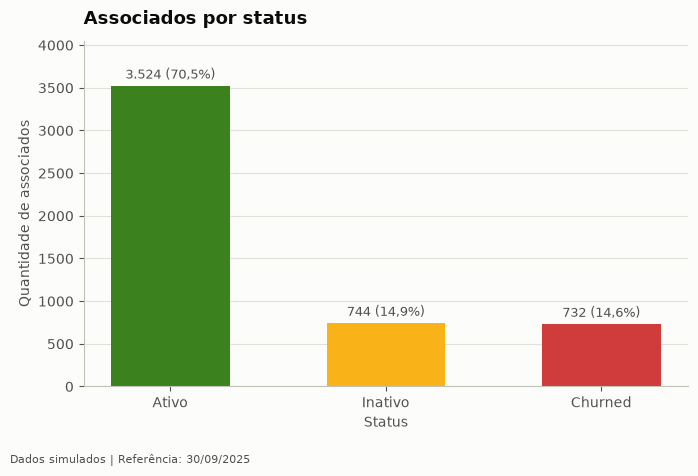

In [9]:
qtd_status = df["status"].value_counts().reindex(ORDEM_STATUS)
pct_status = qtd_status / len(df) * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(qtd_status.index, qtd_status.values,
                color=[CORES_STATUS[s] for s in ORDEM_STATUS], width=0.55)
rotular(ax, barras, [f"{fmt_num(n, 0)} ({fmt_pct(p)})" for n, p in zip(qtd_status, pct_status)])
ax.set_title("Associados por status")
ax.set_xlabel("Status")
ax.set_ylabel("Quantidade de associados")
ax.set_ylim(0, qtd_status.max() * 1.15)
ax.grid(axis="x", visible=False)
salvar(fig, "01_associados_por_status")

### 1.2 Distribuição por estado, segmento e canal de aquisição

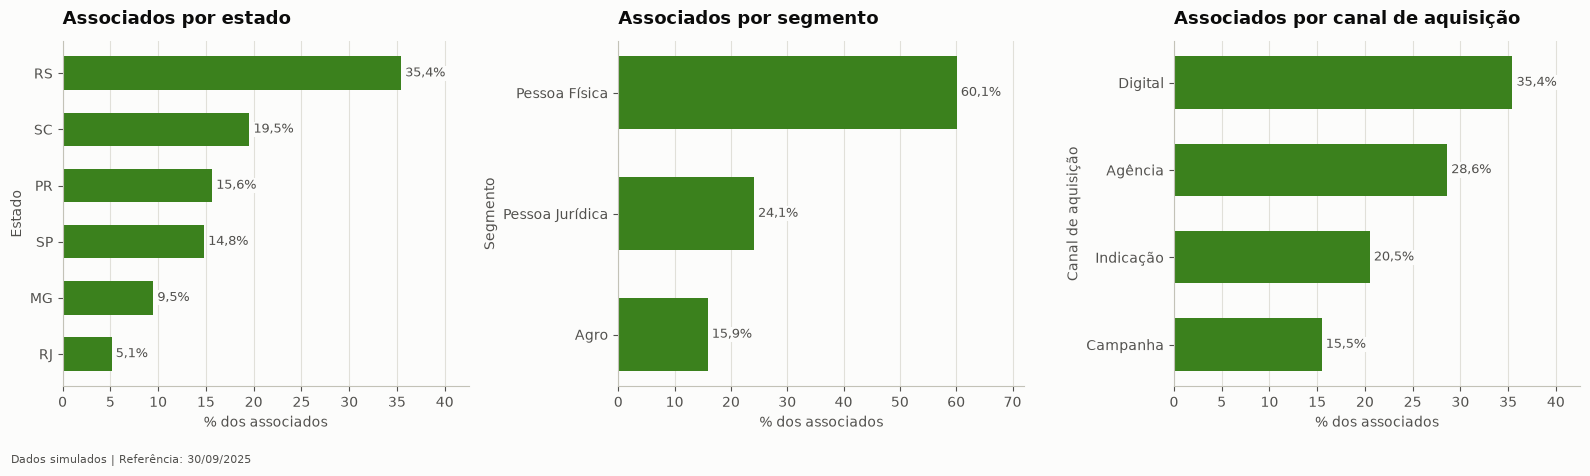

Associados por cidade:
cidade
Porto Alegre      1089
São Paulo          740
Caxias do Sul      682
Florianópolis      504
Curitiba           494
Belo Horizonte     474
Joinville          473
Londrina           288
Rio de Janeiro     256
Name: count, dtype: int64


In [10]:
dimensoes = [("estado", "Estado"), ("segmento", "Segmento"), ("canal_aquisicao", "Canal de aquisição")]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (coluna, nome) in zip(axes, dimensoes):
    distribuicao = df[coluna].value_counts(normalize=True).sort_values() * 100
    barras = ax.barh(distribuicao.index, distribuicao.values, color=VERDE, height=0.6)
    rotular(ax, barras, [fmt_pct(v) for v in distribuicao.values])
    ax.set_title(f"Associados por {nome.lower()}")
    ax.set_xlabel("% dos associados")
    ax.set_ylabel(nome)
    ax.set_xlim(0, distribuicao.max() * 1.2)
    ax.grid(axis="y", visible=False)
salvar(fig, "02_distribuicao_estado_segmento_canal")

print("Associados por cidade:")
print(df["cidade"].value_counts())

### 1.3 Distribuição de idade

Nos registros de Pessoa Jurídica, a idade é a de um responsável fictício pela empresa, e não a
idade da empresa.

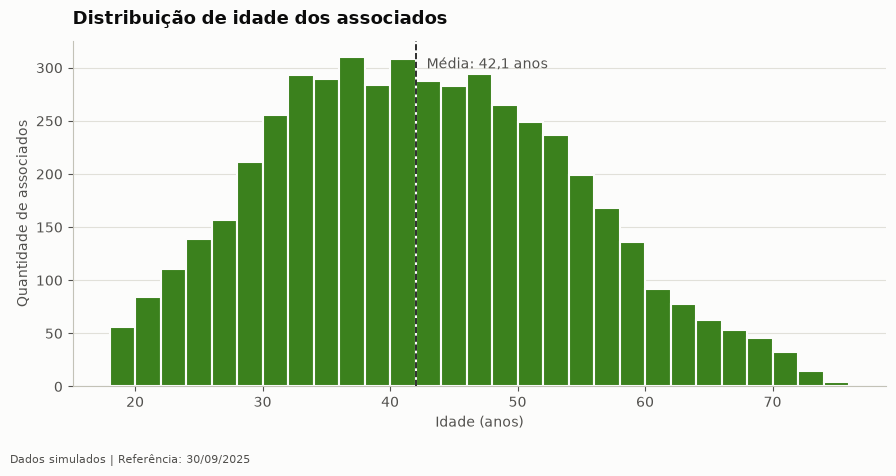

Idade por canal de aquisição:
                 média  mediana
canal_aquisicao                
Agência           45.9     46.0
Campanha          46.3     46.0
Digital           35.0     34.0
Indicação         45.8     46.0


In [11]:
media_idade = df["idade"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df["idade"], bins=range(18, 77, 2), color=VERDE, edgecolor="#fcfcfb", linewidth=1.5)
ax.axvline(media_idade, color="#0b0b0b", linestyle="--", linewidth=1.2)
ax.text(media_idade + 0.8, ax.get_ylim()[1] * 0.92, f"Média: {fmt_num(media_idade)} anos", color=TEXTO_SECUNDARIO)
ax.set_title("Distribuição de idade dos associados")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Quantidade de associados")
ax.grid(axis="x", visible=False)
salvar(fig, "03_histograma_idade")

print("Idade por canal de aquisição:")
print(df.groupby("canal_aquisicao")["idade"].agg(["mean", "median"]).round(1).rename(columns={"mean": "média", "median": "mediana"}))

### 1.4 Novas associações por ano e por mês

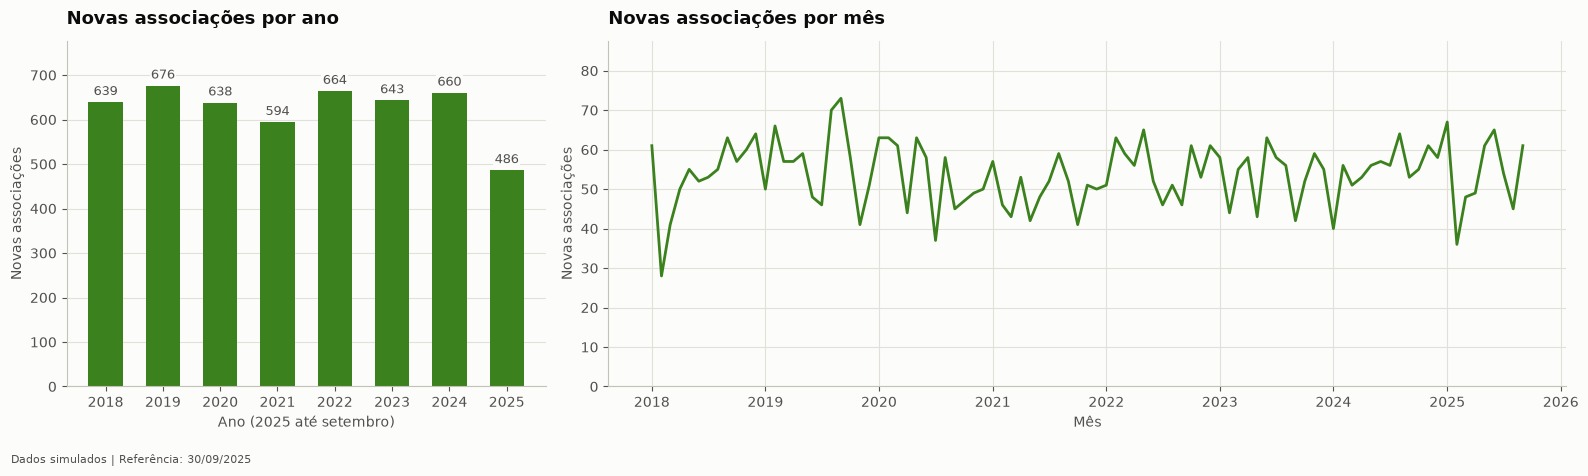

Média mensal de novas associações: 53,8


In [12]:
datas = pd.to_datetime(df["data_associacao"])
por_ano = datas.dt.year.value_counts().sort_index()
por_mes = datas.dt.to_period("M").value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5), gridspec_kw={"width_ratios": [1, 2]})

ax = axes[0]
barras = ax.bar(por_ano.index.astype(str), por_ano.values, color=VERDE, width=0.6)
rotular(ax, barras, [fmt_num(v, 0) for v in por_ano.values])
ax.set_title("Novas associações por ano")
ax.set_xlabel("Ano (2025 até setembro)")
ax.set_ylabel("Novas associações")
ax.set_ylim(0, por_ano.max() * 1.15)
ax.grid(axis="x", visible=False)

ax = axes[1]
ax.plot(por_mes.index.to_timestamp(), por_mes.values, color=VERDE, linewidth=2)
ax.set_title("Novas associações por mês")
ax.set_xlabel("Mês")
ax.set_ylabel("Novas associações")
ax.set_ylim(0, por_mes.max() * 1.2)

salvar(fig, "04_novas_associacoes")

print(f"Média mensal de novas associações: {fmt_num(por_mes.mean())}")

**O que o resultado mostra:**
- **70,5%** dos 5.000 associados estão ativos, 14,9% estão inativos e 14,6% têm status Churned.
- A base é concentrada no Sul: **RS tem 35,4%** dos associados e, somando SC e PR, a região chega
  a cerca de 70%. Porto Alegre é a cidade com mais associados.
- **Pessoa Física** é 60,1% da base, seguida de Pessoa Jurídica (24,1%) e Agro (15,9%).
- **Digital** é o principal canal de aquisição (35,4%) e traz um público bem mais jovem:
  idade média de 35 anos, contra cerca de 46 nos demais canais. A idade média geral é 42,1 anos.
- As novas associações são estáveis ao longo do tempo, com cerca de 650 por ano e média de
  54 por mês. Em 2025 (até setembro) o ritmo se mantém.

## 2. Produtos e cross-sell

**Pergunta de negócio:** quais categorias de produtos os associados já têm, quantas categorias
cada um tem em média, quais costumam aparecer juntas e onde está a oportunidade de venda cruzada?

**Análise:** penetração de cada categoria, distribuição da quantidade de categorias por associado,
correlação entre a posse das categorias e o tamanho do público de associados ativos com conta
corrente e sem cartão de crédito.

A base registra seis categorias de produtos. "Seguros" indica a posse de pelo menos um seguro, de
qualquer modalidade, porque a base não separa os tipos. A contagem é de categorias, não de
contratos, e os investimentos ficam fora dela (são analisados em valor).

### 2.1 Penetração das categorias de produtos

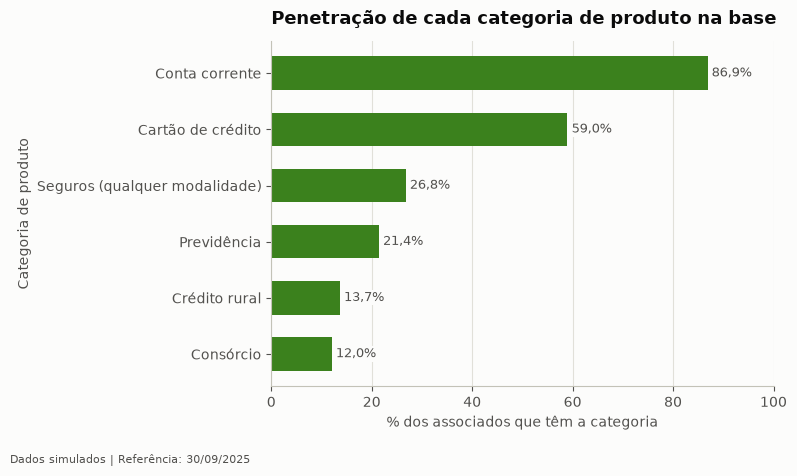

Penetração do crédito rural por segmento (%):
segmento
Agro               69.1
Pessoa Física       3.1
Pessoa Jurídica     3.6
Name: tem_credito_rural, dtype: float64


In [13]:
nomes_produtos = {
    "tem_conta_corrente": "Conta corrente",
    "tem_cartao_credito": "Cartão de crédito",
    "tem_seguro": "Seguros (qualquer modalidade)",
    "tem_consorcio": "Consórcio",
    "tem_previdencia": "Previdência",
    "tem_credito_rural": "Crédito rural",
}
penetracao = (df[colunas_produtos].mean() * 100).rename(nomes_produtos).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.barh(penetracao.index, penetracao.values, color=VERDE, height=0.6)
rotular(ax, barras, [fmt_pct(v) for v in penetracao.values])
ax.set_title("Penetração de cada categoria de produto na base")
ax.set_xlabel("% dos associados que têm a categoria")
ax.set_ylabel("Categoria de produto")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
salvar(fig, "05_penetracao_produtos")

print("Penetração do crédito rural por segmento (%):")
print((df.groupby("segmento")["tem_credito_rural"].mean() * 100).round(1))

### 2.2 Quantidade de categorias de produtos por associado

Média de categorias de produtos por associado: 2,20

Média de categorias por segmento e por status:
segmento
Agro               2.73
Pessoa Física      2.05
Pessoa Jurídica    2.21
Name: qtd_produtos, dtype: float64
status
Ativo      2.44
Inativo    1.93
Churned    1.31
Name: qtd_produtos, dtype: float64


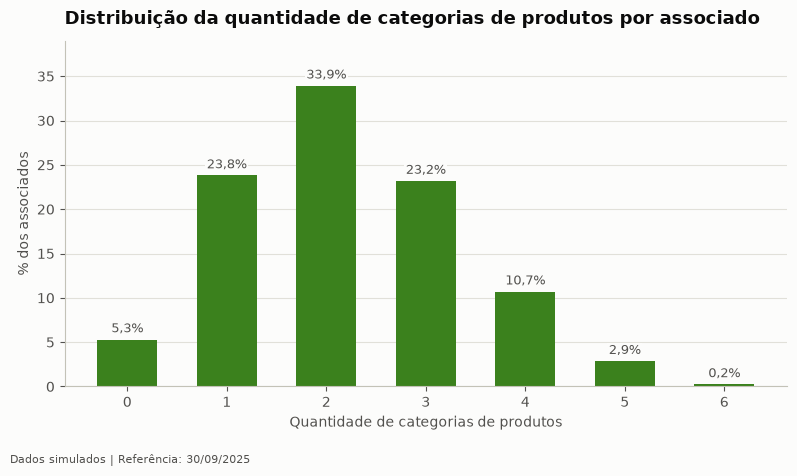

In [14]:
print(f"Média de categorias de produtos por associado: {fmt_num(df['qtd_produtos'].mean(), 2)}")
print()
print("Média de categorias por segmento e por status:")
print(df.groupby("segmento")["qtd_produtos"].mean().round(2))
print(df.groupby("status")["qtd_produtos"].mean().reindex(ORDEM_STATUS).round(2))

dist_produtos = df["qtd_produtos"].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(dist_produtos.index.astype(str), dist_produtos.values, color=VERDE, width=0.6)
rotular(ax, barras, [fmt_pct(v) for v in dist_produtos.values])
ax.set_title("Distribuição da quantidade de categorias de produtos por associado")
ax.set_xlabel("Quantidade de categorias de produtos")
ax.set_ylabel("% dos associados")
ax.set_ylim(0, dist_produtos.max() * 1.15)
ax.grid(axis="x", visible=False)
salvar(fig, "06_distribuicao_qtd_produtos")

### 2.3 Correlação entre a posse das categorias de produtos

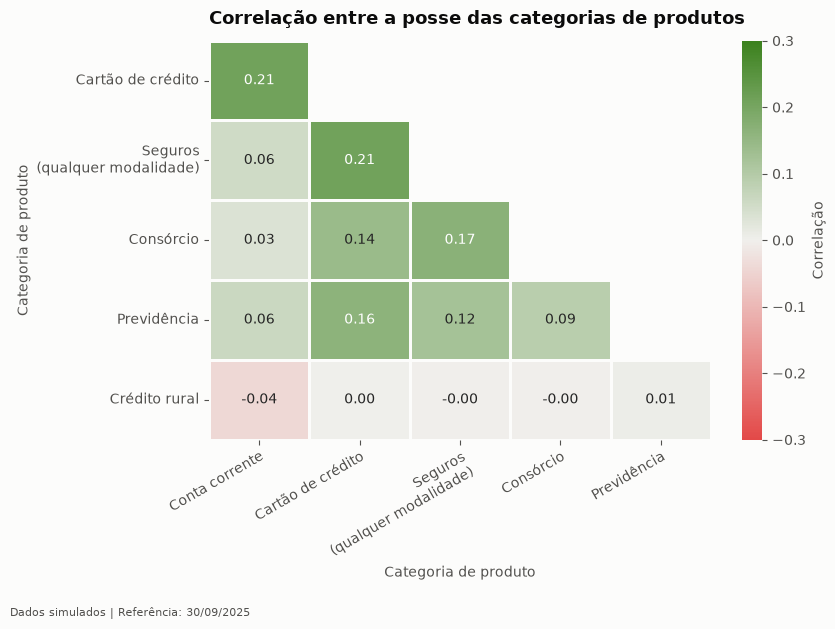

In [15]:
# Nomes em duas linhas quando são longos, para caberem nos eixos do heatmap
nomes_heatmap = {coluna: nome.replace(" (", "\n(") for coluna, nome in nomes_produtos.items()}
correlacao = df[colunas_produtos].rename(columns=nomes_heatmap).corr()
correlacao_triangulo = correlacao.iloc[1:, :-1]
mascara = np.triu(np.ones_like(correlacao_triangulo, dtype=bool), k=1)
limite = np.ceil(correlacao_triangulo.where(~mascara).abs().max().max() * 10) / 10

fig, ax = plt.subplots(figsize=(8.5, 6))
sns.heatmap(correlacao_triangulo, mask=mascara, cmap=CMAP_DIVERGENTE, vmin=-limite, vmax=limite,
            annot=True, fmt=".2f", linewidths=2, linecolor="#fcfcfb",
            cbar_kws={"label": "Correlação"}, ax=ax)
ax.set_title("Correlação entre a posse das categorias de produtos")
ax.set_xlabel("Categoria de produto")
ax.set_ylabel("Categoria de produto")
ax.tick_params(axis="y", rotation=0)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
ax.grid(False)
salvar(fig, "07_heatmap_correlacao_produtos")

### 2.4 Público potencial: associados ativos com conta corrente e sem cartão de crédito

Associados ativos: 3.524
Ativos com conta corrente: 3.197
Ativos com conta corrente e sem cartão: 977 (30,6% dos ativos com conta)


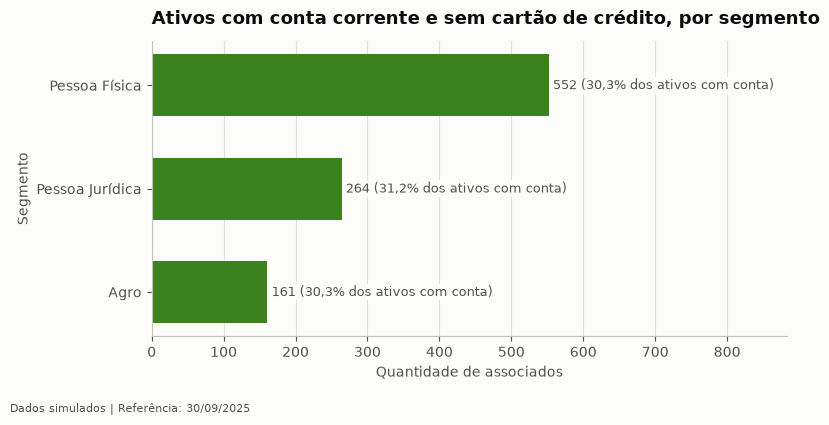

In [16]:
ativos_com_conta = ativos[ativos["tem_conta_corrente"] == 1]
publico_cartao = ativos_com_conta[ativos_com_conta["tem_cartao_credito"] == 0]

print(f"Associados ativos: {fmt_num(len(ativos), 0)}")
print(f"Ativos com conta corrente: {fmt_num(len(ativos_com_conta), 0)}")
print(f"Ativos com conta corrente e sem cartão: {fmt_num(len(publico_cartao), 0)} "
      f"({fmt_pct(len(publico_cartao) / len(ativos_com_conta) * 100)} dos ativos com conta)")

publico_cartao_segmento = pd.DataFrame({
    "associados": publico_cartao.groupby("segmento").size(),
    "pct_ativos_com_conta": (publico_cartao.groupby("segmento").size()
                             / ativos_com_conta.groupby("segmento").size() * 100),
}).sort_values("associados")

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(publico_cartao_segmento.index, publico_cartao_segmento["associados"], color=VERDE, height=0.6)
rotular(ax, barras, [f"{fmt_num(n, 0)} ({fmt_pct(p)} dos ativos com conta)"
                     for n, p in zip(publico_cartao_segmento["associados"], publico_cartao_segmento["pct_ativos_com_conta"])])
ax.set_title("Ativos com conta corrente e sem cartão de crédito, por segmento")
ax.set_xlabel("Quantidade de associados")
ax.set_ylabel("Segmento")
ax.set_xlim(0, publico_cartao_segmento["associados"].max() * 1.6)
ax.grid(axis="y", visible=False)
salvar(fig, "08_oportunidade_cartao_por_segmento")

**O que o resultado mostra:**
- Conta corrente (86,9%) e cartão de crédito (59,0%) são as categorias de entrada. Seguros (26,8%),
  previdência (21,4%), crédito rural (13,7%) e consórcio (12,0%) têm penetração bem menor.
- O crédito rural é praticamente exclusivo do segmento Agro (69,1% dos associados Agro têm o
  produto, contra cerca de 3% nos demais), o que faz do Agro o segmento com mais categorias
  por associado (2,73, contra 2,20 na média geral).
- A média é de **2,20 categorias de produtos por associado** e a maior parte da base tem de 1 a 3.
- O cartão de crédito é a categoria mais ligada às demais: as maiores correlações são dele com
  conta corrente e com seguros (0,21 nos dois casos). Seguros e consórcio também aparecem juntos
  (0,17). As correlações são descritivas: mostram quais categorias aparecem juntas, e não que ter
  uma leve à contratação de outra.
- **977 associados ativos** têm conta corrente e não têm cartão de crédito (30,6% dos ativos com
  conta): 552 em Pessoa Física, 264 em Pessoa Jurídica e 161 no Agro. É um **público potencial**
  para uma oferta de cartão, sujeito a elegibilidade de crédito, interesse e autorização de contato.

**Hipótese a testar:** uma oferta de cartão para esse público, comparada com um grupo de controle,
para medir a contratação adicional gerada pela campanha.

## 3. Segmentação RFV (associados ativos)

**Pergunta de negócio:** como organizar os associados ativos pela intensidade do relacionamento
com a cooperativa?

**Análise:** segmentação RFV com três dimensões:
- **Recência:** `dias_desde_ultimo_acesso`, invertida (quanto menos dias, maior o score);
- **Frequência:** `transacoes_ultimo_trimestre`;
- **Valor:** `saldo_medio_cc`, usado como aproximação do valor do relacionamento (não é receita
  nem lucro).

Cada dimensão é normalizada entre 0 e 1 com `MinMaxScaler` e o score RFV é a média das três.
Como o saldo é muito assimétrico, o score fica concentrado numa faixa estreita. Por isso, as
classes usam os **quartis do score** como limites (cerca de 25% dos ativos em cada uma):
Baixo, Moderado, Alto e Muito alto.

As classes são **relativas**: indicam a posição do associado dentro da base ativa. Um RFV baixo
não é uma previsão de saída.

In [17]:
rfv = ativos[["associado_id", "dias_desde_ultimo_acesso", "transacoes_ultimo_trimestre",
              "saldo_medio_cc", "valor_investido"]].copy()

normalizado = MinMaxScaler().fit_transform(
    rfv[["dias_desde_ultimo_acesso", "transacoes_ultimo_trimestre", "saldo_medio_cc"]])
rfv["score_recencia"] = 1 - normalizado[:, 0]
rfv["score_frequencia"] = normalizado[:, 1]
rfv["score_valor"] = normalizado[:, 2]
rfv["score_rfv"] = rfv[["score_recencia", "score_frequencia", "score_valor"]].mean(axis=1)

ORDEM_RFV = ["Baixo", "Moderado", "Alto", "Muito alto"]
limites_rfv = rfv["score_rfv"].quantile([0, 0.25, 0.5, 0.75, 1]).values
rfv["segmento_rfv"] = pd.cut(rfv["score_rfv"], bins=limites_rfv, labels=ORDEM_RFV, include_lowest=True)

print("Limites do score RFV (quartis):", np.round(limites_rfv, 3))

colunas_score = ["score_recencia", "score_frequencia", "score_valor", "score_rfv"]
rfv[colunas_score] = rfv[colunas_score].round(4)
rfv[["associado_id", *colunas_score, "segmento_rfv", "saldo_medio_cc", "valor_investido"]].to_csv(
    "../data/associados_rfv.csv", index=False, encoding="utf-8-sig")

resumo_rfv = rfv.groupby("segmento_rfv", observed=True).agg(
    associados=("associado_id", "count"),
    dias_sem_acesso=("dias_desde_ultimo_acesso", "mean"),
    transacoes=("transacoes_ultimo_trimestre", "mean"),
    saldo_medio_cc=("saldo_medio_cc", "mean"),
    valor_investido=("valor_investido", "mean"),
    score_rfv=("score_rfv", "mean"),
).round(2)
resumo_rfv

Limites do score RFV (quartis): [0.038 0.346 0.38  0.419 0.712]


,associados,dias_sem_acesso,transacoes,saldo_medio_cc,valor_investido,score_rfv
segmento_rfv,,,,,,
Baixo,881,23.81,21.75,3030.31,11960.03,0.31
Moderado,881,10.03,26.18,4077.80,9826.39,0.36
Alto,881,7.40,35.85,6201.05,11316.30,0.40
Muito alto,881,7.08,56.20,16601.00,11888.77,0.47


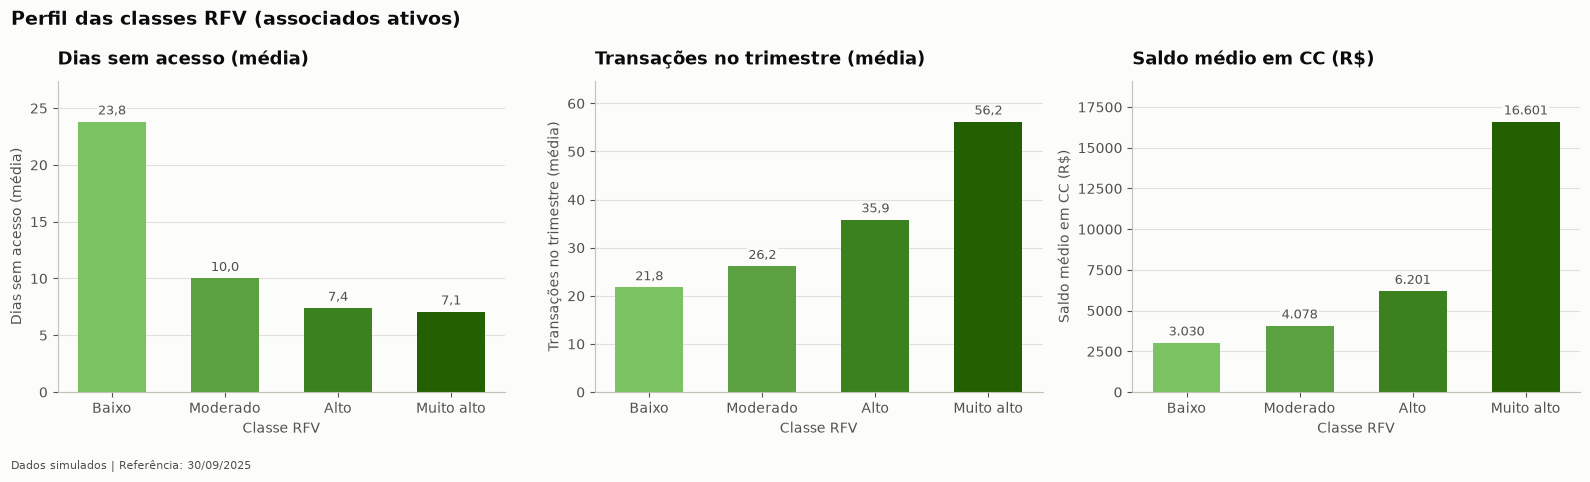

In [18]:
metricas_rfv = [
    ("dias_sem_acesso", "Dias sem acesso (média)"),
    ("transacoes", "Transações no trimestre (média)"),
    ("saldo_medio_cc", "Saldo médio em CC (R$)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (coluna, nome) in zip(axes, metricas_rfv):
    valores = resumo_rfv[coluna]
    barras = ax.bar(valores.index.astype(str), valores.values, color=RAMPA_VERDE, width=0.6)
    casas = 0 if coluna == "saldo_medio_cc" else 1
    rotular(ax, barras, [fmt_num(v, casas) for v in valores.values])
    ax.set_title(nome)
    ax.set_xlabel("Classe RFV")
    ax.set_ylabel(nome)
    ax.set_ylim(0, valores.max() * 1.15)
    ax.grid(axis="x", visible=False)
fig.suptitle("Perfil das classes RFV (associados ativos)", x=0.01, ha="left", fontsize=14, fontweight="bold")
salvar(fig, "09_perfil_segmentos_rfv")

**O que o resultado mostra:**
- Cada classe reúne 881 associados ativos (um quarto da base ativa), porque os cortes são os
  quartis do score.
- A classe **Muito alto** se destaca em frequência e valor: 56,2 transações no trimestre e saldo
  médio de cerca de R$ 16,6 mil, mais de 5 vezes o saldo da classe Baixo (cerca de R$ 3,0 mil).
- A classe **Baixo** ainda é ativa, mas acumula 24 dias sem acesso em média, contra 7 a 10 dias
  nas outras classes.
- **Alto** e **Moderado** têm recência parecida com a da classe Muito alto, mas movimentam e
  guardam menos.
- O valor investido quase não muda entre as classes (de R$ 9,8 mil a R$ 12,0 mil), porque ele não
  faz parte do score.
- A classificação completa foi exportada em `data/associados_rfv.csv`.

**Hipóteses a testar:** ações de reengajamento para a classe Baixo, campanhas para aumentar o uso
e o saldo nas classes Moderado e Alto, e ofertas de investimento em todas as classes. Para prever
saídas, seria preciso ter o histórico de comportamento anterior ao evento.

## 4. NPS

**Pergunta de negócio:** os associados recomendariam a cooperativa? A recomendação muda entre
segmentos, estados e canais de aquisição? Ela tem relação com a quantidade de categorias de
produtos e com o uso do app?

**Análise:** cada associado tem uma **nota de recomendação** de 0 a 10. As notas são classificadas
em Promotores (9 ou 10), Neutros (7 ou 8) e Detratores (0 a 6). O **NPS** é o percentual de
promotores menos o percentual de detratores, calculado sobre todas as respostas, incluindo os
neutros. Ele vai de -100 a +100 pontos.

A média das notas é um indicador diferente e não deve ser chamada de NPS. Nesta base simulada,
todos os 5.000 associados têm uma nota.

Respostas: 5.000
Composição das respostas (%):
nps_score
Promotor    43.2
Neutro      35.4
Detrator    21.4
Name: proportion, dtype: float64

NPS geral: 21,8 pontos
Nota média de recomendação (0 a 10): 7,93


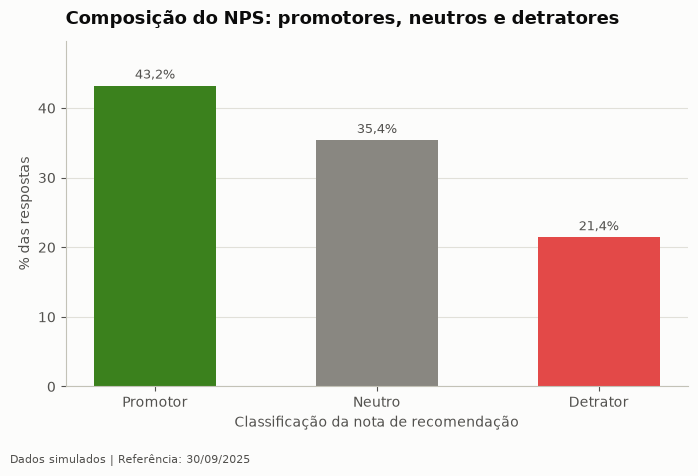

In [19]:
def calcular_nps(notas):
    return ((notas >= 9).mean() - (notas <= 6).mean()) * 100


categoria_nps = pd.cut(df["nps_score"], bins=[-1, 6, 8, 10], labels=["Detrator", "Neutro", "Promotor"])
composicao_nps = categoria_nps.value_counts(normalize=True).reindex(["Promotor", "Neutro", "Detrator"]) * 100
nps_geral = calcular_nps(df["nps_score"])
nota_media = df["nps_score"].mean()

print(f"Respostas: {fmt_num(df['nps_score'].notna().sum(), 0)}")
print("Composição das respostas (%):")
print(composicao_nps.round(1))
print()
print(f"NPS geral: {fmt_num(nps_geral)} pontos")
print(f"Nota média de recomendação (0 a 10): {fmt_num(nota_media, 2)}")

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.bar(composicao_nps.index.astype(str), composicao_nps.values,
                color=[VERDE, CINZA, VERMELHO], width=0.55)
rotular(ax, barras, [fmt_pct(v) for v in composicao_nps.values])
ax.set_title("Composição do NPS: promotores, neutros e detratores")
ax.set_xlabel("Classificação da nota de recomendação")
ax.set_ylabel("% das respostas")
ax.set_ylim(0, composicao_nps.max() * 1.15)
ax.grid(axis="x", visible=False)
salvar(fig, "17_composicao_nps")

### 4.1 NPS por segmento, estado e canal de aquisição

NPS por estado: {'RS': 18.5, 'PR': 20.1, 'SP': 20.9, 'SC': 24.3, 'RJ': 27.7, 'MG': 30.0}
NPS por segmento: {'Pessoa Física': 17.7, 'Pessoa Jurídica': 20.2, 'Agro': 39.5}
NPS por canal de aquisição: {'Digital': 17.6, 'Agência': 23.2, 'Indicação': 24.5, 'Campanha': 25.2}


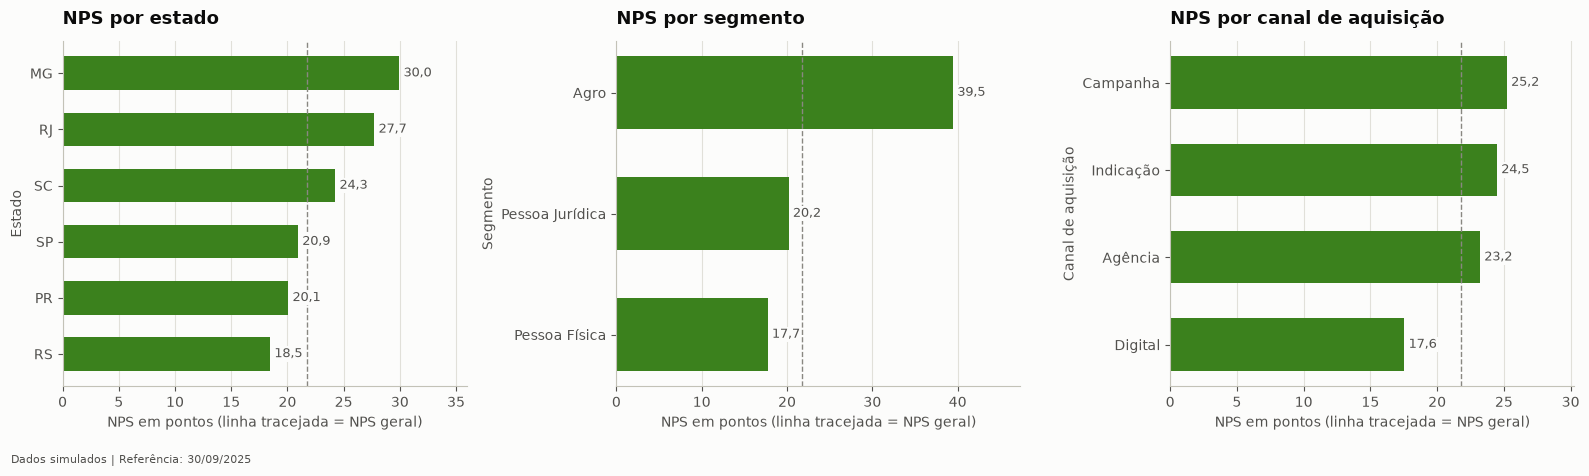

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (coluna, nome) in zip(axes, dimensoes):
    nps_grupo = df.groupby(coluna)["nps_score"].agg(calcular_nps).sort_values()
    barras = ax.barh(nps_grupo.index, nps_grupo.values, color=VERDE, height=0.6)
    rotular(ax, barras, [fmt_num(v) for v in nps_grupo.values])
    ax.axvline(nps_geral, color="#898781", linestyle="--", linewidth=1, zorder=1)
    ax.set_title(f"NPS por {nome.lower()}")
    ax.set_xlabel("NPS em pontos (linha tracejada = NPS geral)")
    ax.set_ylabel(nome)
    ax.set_xlim(0, nps_grupo.max() * 1.2)
    ax.grid(axis="y", visible=False)
    print(f"NPS por {nome.lower()}:", nps_grupo.round(1).to_dict())
salvar(fig, "10_nps_por_segmento_estado_canal")

### 4.2 NPS por quantidade de categorias de produtos e por uso do app

Para evitar grupos muito pequenos, associados com 5 ou 6 categorias foram agrupados em "5 ou mais".
As barras em vermelho indicam NPS negativo.

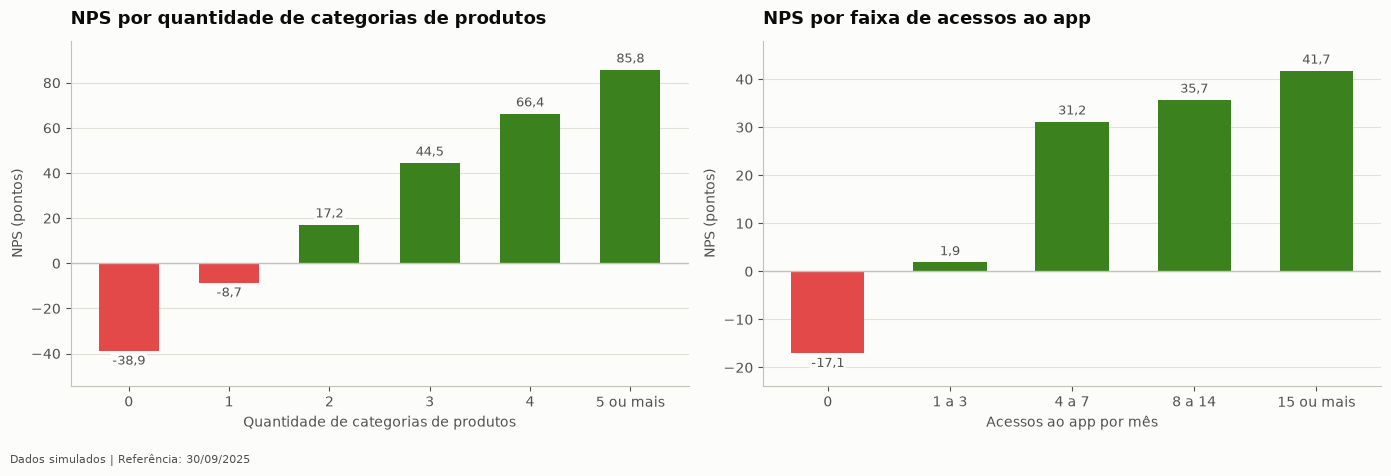

NPS por quantidade de categorias de produtos:
              associados   nps
qtd_produtos                  
0                    265 -38.9
1                   1190  -8.7
2                   1696  17.2
3                   1159  44.5
4                    535  66.4
5 ou mais            155  85.8

NPS por faixa de acessos ao app:
                 associados   nps
acessos_app_mes                  
0                       557 -17.1
1 a 3                  1122   1.9
4 a 7                  1300  31.2
8 a 14                 1415  35.7
15 ou mais              606  41.7


In [21]:
faixa_produtos = df["qtd_produtos"].clip(upper=5).map(lambda q: "5 ou mais" if q == 5 else str(q))
nps_produtos = df.groupby(faixa_produtos)["nps_score"].agg(["count", calcular_nps])
nps_produtos.columns = ["associados", "nps"]

faixa_acessos = pd.cut(df["acessos_app_mes"], bins=[-1, 0, 3, 7, 14, np.inf],
                       labels=["0", "1 a 3", "4 a 7", "8 a 14", "15 ou mais"])
nps_acessos = df.groupby(faixa_acessos, observed=True)["nps_score"].agg(["count", calcular_nps])
nps_acessos.columns = ["associados", "nps"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, tabela, nome_x, titulo in [
    (axes[0], nps_produtos, "Quantidade de categorias de produtos", "NPS por quantidade de categorias de produtos"),
    (axes[1], nps_acessos, "Acessos ao app por mês", "NPS por faixa de acessos ao app"),
]:
    barras = ax.bar(tabela.index.astype(str), tabela["nps"],
                    color=[VERMELHO if v < 0 else VERDE for v in tabela["nps"]], width=0.6)
    rotular(ax, barras, [fmt_num(v) for v in tabela["nps"]])
    ax.axhline(0, color="#c3c2b7", linewidth=1)
    ax.set_title(titulo)
    ax.set_xlabel(nome_x)
    ax.set_ylabel("NPS (pontos)")
    ax.set_ylim(min(0, tabela["nps"].min() * 1.4), tabela["nps"].max() * 1.15)
    ax.grid(axis="x", visible=False)
salvar(fig, "11_nps_por_produtos_e_acessos")

print("NPS por quantidade de categorias de produtos:")
print(nps_produtos.round(1))
print()
print("NPS por faixa de acessos ao app:")
print(nps_acessos.round(1))

**O que o resultado mostra:**
- **NPS geral de 21,8 pontos**, com 43,2% de promotores, 35,4% de neutros e 21,4% de detratores.
  A nota média de recomendação é 7,93, em uma escala de 0 a 10.
- **Agro tem o NPS mais alto (39,5)**, bem acima de Pessoa Jurídica (20,2) e Pessoa Física (17,7).
- Entre os canais de aquisição, **Digital tem o menor NPS (17,6)**. Esse público é mais jovem e
  tem menos categorias de produtos (previdência, por exemplo, é menos comum entre os mais jovens),
  o que, nesta simulação, se reflete em notas mais baixas.
- Entre os estados, o NPS varia de 18,5 (RS) a 30,0 (MG). RS é o maior estado da base, então o
  NPS mais baixo ali tem peso relevante no resultado geral.
- A relação com a **quantidade de categorias de produtos** é a mais forte: o NPS vai de -38,9
  entre quem não tem nenhuma para 85,8 entre quem tem 5 ou mais.
- O **uso do app** também acompanha a recomendação: quem não acessou o app no mês tem NPS negativo
  (-17,1), enquanto quem acessa 15 vezes ou mais chega a 41,7.

**Limite da leitura:** a relação entre categorias de produtos e nota foi definida na geração dos
dados. Ela mostra uma associação e não prova que contratar mais produtos aumenta a recomendação.
Em uma base real, a hipótese pode ser testada acompanhando a nota antes e depois da contratação.

**Ação proposta:** ouvir os detratores para entender os motivos da nota e priorizar melhorias de
experiência.

## 5. Churn

**Pergunta de negócio:** que parcela da base tem status de saída (Churned), em quais segmentos
ela é maior e o que diferencia esses associados dos que continuam ativos?

**Análise:** taxa de churn geral e por segmento, comparação do perfil médio de Churned e Ativos
e ranking das variáveis que mais separam os dois grupos.

**Definição usada:** taxa de churn = associados com status Churned / total de associados da base.
É uma fotografia em 30/09/2025: a base não tem data de saída nem histórico, então o indicador
**não é uma taxa mensal ou anual de churn**.

Taxa de churn (Churned / total da base): 14,6%


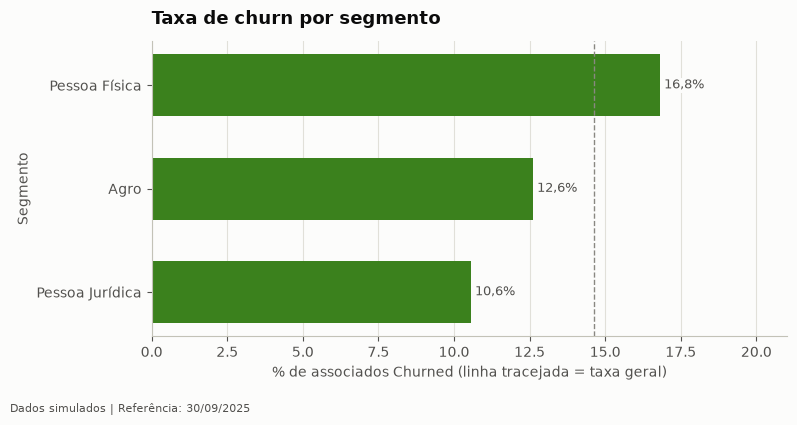

In [22]:
taxa_churn = (df["status"] == "Churned").mean() * 100
print(f"Taxa de churn (Churned / total da base): {fmt_pct(taxa_churn)}")

churn_segmento = (df.groupby("segmento")["status"].apply(lambda s: (s == "Churned").mean()) * 100).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
barras = ax.barh(churn_segmento.index, churn_segmento.values, color=VERDE, height=0.6)
rotular(ax, barras, [fmt_pct(v) for v in churn_segmento.values])
ax.axvline(taxa_churn, color="#898781", linestyle="--", linewidth=1, zorder=1)
ax.set_title("Taxa de churn por segmento")
ax.set_xlabel("% de associados Churned (linha tracejada = taxa geral)")
ax.set_ylabel("Segmento")
ax.set_xlim(0, churn_segmento.max() * 1.25)
ax.grid(axis="y", visible=False)
salvar(fig, "12_churn_por_segmento")

### 5.1 Churn por tempo de associação

Tempo de associação = anos entre a data de associação e 30/09/2025 (data de referência da base).
Esse tempo é contado até a data de referência para todos, inclusive para quem saiu, porque a
base não registra a data da saída. Por isso, o gráfico compara grupos pela **época em que
entraram**, e não pelo tempo que cada associado ficou até sair.

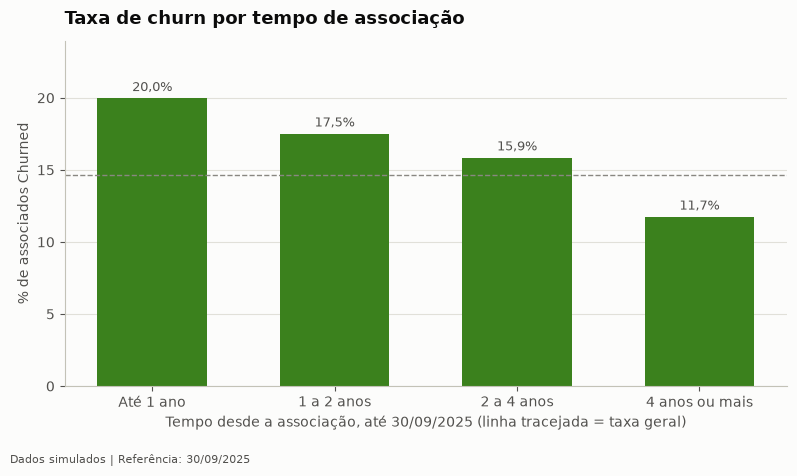

,associados,taxa_churn
tempo_associacao,,
Até 1 ano,661,20.0
1 a 2 anos,651,17.5
2 a 4 anos,1287,15.9
4 anos ou mais,2401,11.7


In [23]:
fim_periodo = pd.Timestamp("2025-09-30")
anos_associacao = (fim_periodo - pd.to_datetime(df["data_associacao"])).dt.days / 365.25
faixa_tempo = pd.cut(anos_associacao, bins=[0, 1, 2, 4, 8],
                     labels=["Até 1 ano", "1 a 2 anos", "2 a 4 anos", "4 anos ou mais"],
                     include_lowest=True).rename("tempo_associacao")
churn_tempo = df.groupby(faixa_tempo, observed=True)["status"].agg(
    associados="count", taxa_churn=lambda s: (s == "Churned").mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(churn_tempo.index.astype(str), churn_tempo["taxa_churn"], color=VERDE, width=0.6)
rotular(ax, barras, [fmt_pct(v) for v in churn_tempo["taxa_churn"]])
ax.axhline(taxa_churn, color="#898781", linestyle="--", linewidth=1, zorder=1)
ax.set_title("Taxa de churn por tempo de associação")
ax.set_xlabel("Tempo desde a associação, até 30/09/2025 (linha tracejada = taxa geral)")
ax.set_ylabel("% de associados Churned")
ax.set_ylim(0, churn_tempo["taxa_churn"].max() * 1.2)
ax.grid(axis="x", visible=False)
salvar(fig, "16_churn_por_tempo_associacao")

churn_tempo.round(1)

### 5.2 Perfil Churned x Ativo

In [24]:
variaveis_perfil = {
    "idade": "Idade",
    "qtd_produtos": "Categorias de produtos",
    "nps_score": "Nota de recomendação (0 a 10)",
    "dias_desde_ultimo_acesso": "Dias sem acesso",
    "transacoes_ultimo_trimestre": "Transações no trimestre",
}
df["anos_associacao"] = anos_associacao.round(2)
ativos = df[df["status"] == "Ativo"]
churned = df[df["status"] == "Churned"]

perfil = pd.DataFrame({
    "Ativo": ativos[list(variaveis_perfil)].mean(),
    "Churned": churned[list(variaveis_perfil)].mean(),
}).rename(index=variaveis_perfil)
perfil["Diferença (%)"] = (perfil["Churned"] / perfil["Ativo"] - 1) * 100
perfil.round(2)

,Ativo,Churned,Diferença (%)
Idade,41.79,42.73,2.25
Categorias de produtos,2.44,1.31,-46.22
Nota de recomendação (0 a 10),8.27,6.69,-19.12
Dias sem acesso,12.08,221.70,1735.76
Transações no trimestre,35.00,2.05,-94.14


### 5.3 Variáveis que mais diferenciam Churned e Ativos

Para comparar variáveis com escalas diferentes, a diferença entre as médias foi dividida pelo
desvio padrão combinado dos dois grupos (diferença padronizada). Valores acima de 0 indicam
média maior entre os Churned; abaixo de 0, média menor.

Observação: dias sem acesso, transações e acessos ao app aparecem à frente das demais porque, na
geração dos dados, são ajustados depois do sorteio do status. Nesta base eles são consequência
do status e não servem como sinal antecipado de saída. A comparação é descritiva.

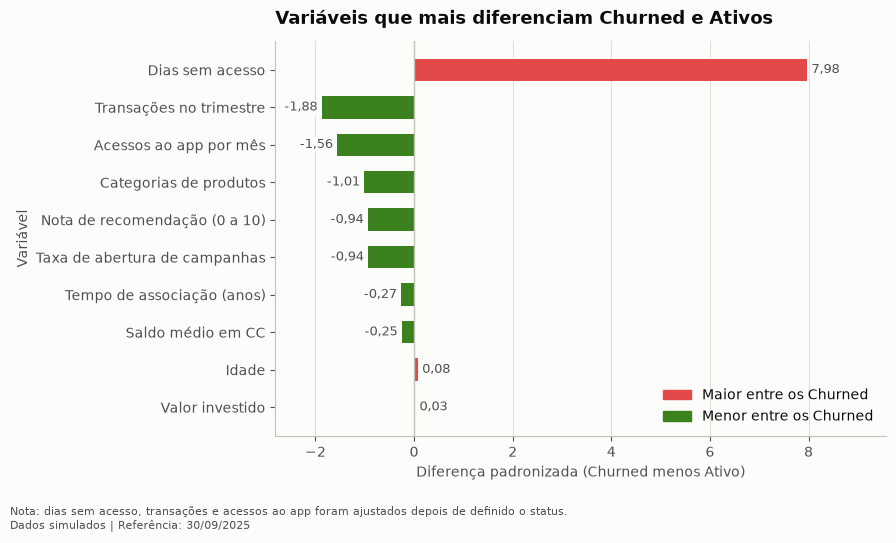

Transações no trimestre         -1.88
Acessos ao app por mês          -1.56
Categorias de produtos          -1.01
Nota de recomendação (0 a 10)   -0.94
Taxa de abertura de campanhas   -0.94
Tempo de associação (anos)      -0.27
Saldo médio em CC               -0.25
Valor investido                  0.03
Idade                            0.08
Dias sem acesso                  7.98
dtype: float64

In [25]:
variaveis_diferenca = {
    **variaveis_perfil,
    "acessos_app_mes": "Acessos ao app por mês",
    "saldo_medio_cc": "Saldo médio em CC",
    "valor_investido": "Valor investido",
    "taxa_abertura_campanha": "Taxa de abertura de campanhas",
    "anos_associacao": "Tempo de associação (anos)",
}


def diferenca_padronizada(coluna):
    a, c = ativos[coluna], churned[coluna]
    desvio_combinado = np.sqrt(((len(a) - 1) * a.var() + (len(c) - 1) * c.var()) / (len(a) + len(c) - 2))
    return (c.mean() - a.mean()) / desvio_combinado


diferencas = pd.Series({nome: diferenca_padronizada(col) for col, nome in variaveis_diferenca.items()})
diferencas = diferencas.reindex(diferencas.abs().sort_values().index)

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(diferencas.index, diferencas.values,
                 color=[VERMELHO if v > 0 else VERDE for v in diferencas.values], height=0.6)
rotular(ax, barras, [fmt_num(v, 2) for v in diferencas.values])
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_title("Variáveis que mais diferenciam Churned e Ativos")
ax.set_xlabel("Diferença padronizada (Churned menos Ativo)")
ax.set_ylabel("Variável")
ax.set_xlim(diferencas.min() * 1.5, diferencas.max() * 1.2)
ax.grid(axis="y", visible=False)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=VERMELHO), plt.Rectangle((0, 0), 1, 1, color=VERDE)],
          labels=["Maior entre os Churned", "Menor entre os Churned"], loc="lower right", frameon=False)
salvar(fig, "13_diferencas_churned_ativo",
       nota="Nota: dias sem acesso, transações e acessos ao app foram ajustados depois de definido o status.")

diferencas.sort_values().round(2)

**O que o resultado mostra:**
- A **taxa de churn é de 14,6%** (732 dos 5.000 associados têm status Churned). Pessoa Física tem
  a maior taxa (16,8%), acima de Agro (12,6%) e Pessoa Jurídica (10,6%).
- Entre quem se associou há até 1 ano, 20,0% têm status Churned, contra 11,7% entre quem se
  associou há 4 anos ou mais. Isso mostra uma diferença entre grupos de entrada. Não dá para
  concluir que o primeiro ano é o período de maior risco, porque a base não informa quando cada
  saída aconteceu.
- Os associados Churned têm, em média, **46% menos categorias de produtos** (1,31 contra 2,44) e
  nota média de recomendação mais baixa (6,69 contra 8,27). Idade, saldo e valor investido
  praticamente não diferenciam os grupos.
- Dias sem acesso, transações e acessos ao app são as variáveis que mais separam os grupos, mas
  nesta base elas refletem o próprio status. Em dados reais, a queda de uso costuma ser
  acompanhada como sinal de alerta. Para confirmar isso, seria preciso ter o histórico de uso
  anterior à saída.

**Hipóteses a testar:** se ampliar o relacionamento (mais categorias de produtos) e tratar os
motivos dos detratores reduz o churn. Um estudo de retenção precisa de datas de saída, do
comportamento anterior ao evento e de um grupo de comparação.

## 6. KPIs de marketing

**Pergunta de negócio:** como os associados respondem às campanhas? Quais segmentos e quais
origens de aquisição respondem melhor e onde vale concentrar os próximos testes?

**Análise:** considerando os associados que receberam pelo menos uma campanha:
- **Taxa de abertura** = campanhas abertas / campanhas recebidas;
- **Conversão sobre aberturas** = campanhas convertidas / campanhas abertas;
- **Conversão sobre recebimentos** = campanhas convertidas / campanhas recebidas (funil completo).

As taxas usam a razão entre os totais, e não a média das taxas individuais. As contagens são
ocorrências por associado (quantas campanhas cada um recebeu, abriu e converteu), não campanhas
únicas.

**Atenção:** o canal de aquisição indica por onde o associado entrou na cooperativa (Agência,
Digital, Indicação ou Campanha). Ele não é o canal pelo qual as campanhas foram enviadas.

In [26]:
receberam = df[df["campanhas_recebidas"] > 0]
colunas_campanha = ["campanhas_recebidas", "campanhas_abertas", "campanhas_convertidas"]


def taxas_campanha(coluna):
    somas = receberam.groupby(coluna)[colunas_campanha].sum()
    return pd.DataFrame({
        "associados": receberam.groupby(coluna).size(),
        "taxa_abertura": somas["campanhas_abertas"] / somas["campanhas_recebidas"] * 100,
        "conversao_aberturas": somas["campanhas_convertidas"] / somas["campanhas_abertas"] * 100,
        "conversao_recebimentos": somas["campanhas_convertidas"] / somas["campanhas_recebidas"] * 100,
    })


def grafico_taxas(tabela, nome_dimensao, metricas, nome_arquivo):
    fig, axes = plt.subplots(1, len(metricas), figsize=(6 * len(metricas), 4.2))
    for ax, (coluna, titulo, rotulo_eixo) in zip(axes, metricas):
        valores = tabela[coluna].sort_values()
        barras = ax.barh(valores.index, valores.values, color=VERDE, height=0.6)
        rotular(ax, barras, [fmt_pct(v) for v in valores.values])
        ax.set_title(titulo)
        ax.set_xlabel(rotulo_eixo)
        ax.set_ylabel(nome_dimensao)
        ax.set_xlim(0, valores.max() * 1.25)
        ax.grid(axis="y", visible=False)
    salvar(fig, nome_arquivo)


totais = receberam[colunas_campanha].sum()
taxa_abertura_geral = totais["campanhas_abertas"] / totais["campanhas_recebidas"] * 100
conversao_aberturas_geral = totais["campanhas_convertidas"] / totais["campanhas_abertas"] * 100
conversao_recebimentos_geral = totais["campanhas_convertidas"] / totais["campanhas_recebidas"] * 100

print(f"Associados que receberam campanha: {fmt_num(len(receberam), 0)} ({fmt_pct(len(receberam) / len(df) * 100)})")
print(f"Campanhas recebidas: {fmt_num(totais['campanhas_recebidas'], 0)} | "
      f"abertas: {fmt_num(totais['campanhas_abertas'], 0)} | convertidas: {fmt_num(totais['campanhas_convertidas'], 0)}")
print(f"Taxa de abertura geral: {fmt_pct(taxa_abertura_geral)}")
print(f"Conversão sobre aberturas geral: {fmt_pct(conversao_aberturas_geral)}")
print(f"Conversão sobre recebimentos geral: {fmt_pct(conversao_recebimentos_geral)}")

Associados que receberam campanha: 4.986 (99,7%)
Campanhas recebidas: 29.797 | abertas: 11.903 | convertidas: 1.820
Taxa de abertura geral: 39,9%
Conversão sobre aberturas geral: 15,3%
Conversão sobre recebimentos geral: 6,1%


### 6.1 Abertura e conversão por segmento

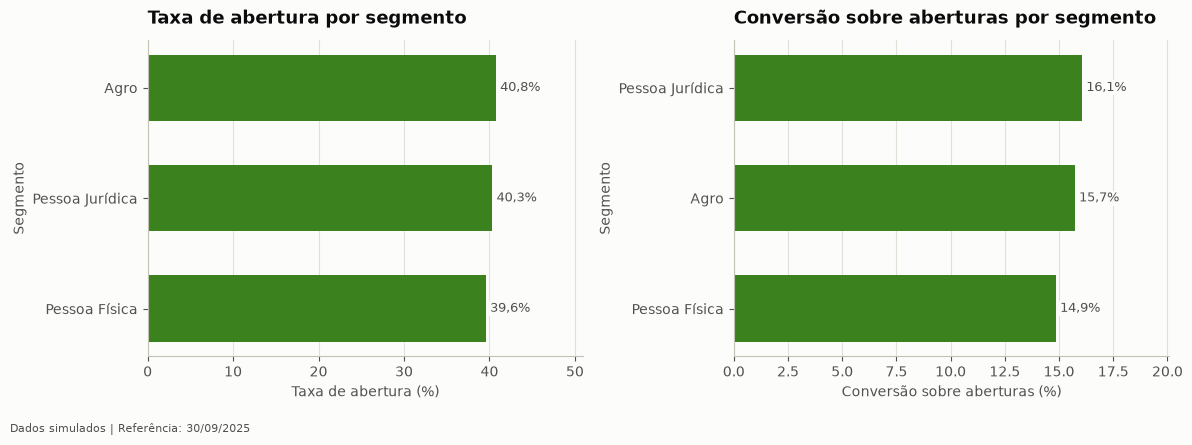

,associados,taxa_abertura,conversao_aberturas,conversao_recebimentos
segmento,,,,
Agro,788,40.8,15.7,6.4
Pessoa Física,2999,39.6,14.9,5.9
Pessoa Jurídica,1199,40.3,16.1,6.5


In [27]:
campanhas_segmento = taxas_campanha("segmento")
grafico_taxas(campanhas_segmento, "Segmento",
              [("taxa_abertura", "Taxa de abertura por segmento", "Taxa de abertura (%)"),
               ("conversao_aberturas", "Conversão sobre aberturas por segmento", "Conversão sobre aberturas (%)")],
              "14_campanhas_por_segmento")
campanhas_segmento.round(1)

### 6.2 Resposta às campanhas por canal de aquisição

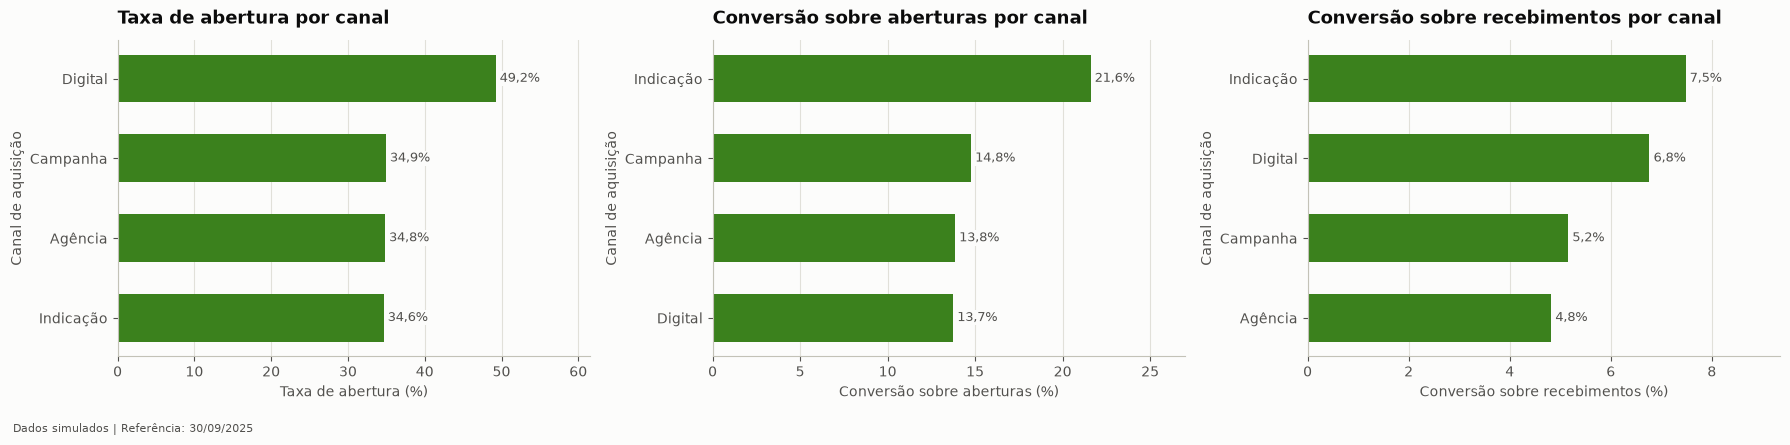

,associados,taxa_abertura,conversao_aberturas,conversao_recebimentos
canal_aquisicao,,,,
Agência,1427,34.8,13.8,4.8
Campanha,772,34.9,14.8,5.2
Digital,1768,49.2,13.7,6.8
Indicação,1019,34.6,21.6,7.5


In [28]:
campanhas_canal = taxas_campanha("canal_aquisicao")
grafico_taxas(campanhas_canal, "Canal de aquisição",
              [("taxa_abertura", "Taxa de abertura por canal", "Taxa de abertura (%)"),
               ("conversao_aberturas", "Conversão sobre aberturas por canal", "Conversão sobre aberturas (%)"),
               ("conversao_recebimentos", "Conversão sobre recebimentos por canal", "Conversão sobre recebimentos (%)")],
              "15_campanhas_por_canal")
campanhas_canal.round(1)

### 6.3 Priorização de segmentos para campanhas

Tabela que junta, por segmento, o tamanho da base ativa, a resposta às campanhas, a taxa de churn,
a participação na classe RFV Baixo e o público potencial de cartão de crédito.

In [29]:
rfv_segmento = rfv.merge(df[["associado_id", "segmento"]], on="associado_id")
priorizacao = pd.DataFrame({
    "ativos": ativos.groupby("segmento").size(),
    "taxa_churn": churn_segmento,
    "taxa_abertura": campanhas_segmento["taxa_abertura"],
    "conversao_aberturas": campanhas_segmento["conversao_aberturas"],
    "pct_ativos_rfv_baixo": rfv_segmento.groupby("segmento")["segmento_rfv"].apply(lambda s: (s == "Baixo").mean() * 100),
    "publico_potencial_cartao": publico_cartao_segmento["associados"],
    "saldo_medio_cc_ativos": ativos.groupby("segmento")["saldo_medio_cc"].mean(),
}).sort_values("ativos", ascending=False)
priorizacao.round(1)

,ativos,taxa_churn,taxa_abertura,conversao_aberturas,pct_ativos_rfv_baixo,publico_potencial_cartao,saldo_medio_cc_ativos
segmento,,,,,,,
Pessoa Física,2039,16.8,39.6,14.9,33.5,552,3651.6
Pessoa Jurídica,880,10.6,40.3,16.1,9.3,264,15884.4
Agro,605,12.6,40.8,15.7,19.0,161,8144.0


**O que o resultado mostra:**
- Praticamente toda a base recebeu campanhas. A **taxa de abertura é de 39,9%**, a **conversão
  sobre aberturas é de 15,3%** e a **conversão sobre recebimentos é de 6,1%**. Os dois últimos
  números medem coisas diferentes: o primeiro olha só para quem abriu, e o segundo para o funil
  completo.
- Entre os segmentos, as taxas são parecidas (abertura de 39,6% a 40,8%, conversão sobre aberturas
  de 14,9% a 16,1%). O segmento, sozinho, não explica a resposta às campanhas.
- A origem do associado faz mais diferença: quem entrou pelo **Digital abre mais** (49,2%), mas
  converte menos sobre as aberturas (13,7%). Quem entrou por **Indicação converte mais** (21,6% das
  aberturas) e tem a maior conversão sobre recebimentos (7,5%, contra 4,8% de quem entrou pela
  Agência).

**Priorização sugerida:**
1. **Pessoa Física: retenção e cross-sell.** É a maior base ativa (2.039), tem a maior taxa de
   churn (16,8%), o menor NPS (17,7), 33,5% dos ativos na classe RFV Baixo e 552 associados com
   conta e sem cartão. É o primeiro público para testar ações de reengajamento e uma oferta de
   cartão de crédito.
2. **Pessoa Jurídica: valor.** Tem o maior saldo médio entre os ativos (cerca de R$ 15,9 mil), a
   menor taxa de churn (10,6%) e só 9,3% dos ativos na classe RFV Baixo. É um público para testar
   ofertas de aprofundamento do relacionamento (cartão, seguros e consórcio), começando pelos 264
   sem cartão.
3. **Agro: manutenção.** Já tem mais categorias de produtos e o maior NPS (39,5). Ações pontuais
   de produtos complementares, com atenção aos 19,0% de ativos na classe RFV Baixo.

**Limites:** as diferenças por canal de aquisição mostram qual origem de associado responde melhor,
e não qual canal de envio funciona melhor. A base não tem janela de campanha, custo nem receita,
então não é possível calcular o retorno. As prioridades acima são hipóteses para testes com grupo
de controle.

## 7. Resumo executivo

Principais indicadores da base em uma única tabela.

In [30]:
kpis = pd.DataFrame({
    "Indicador": [
        "Total de associados",
        "Associados ativos",
        "Taxa de churn (Churned / total da base)",
        "NPS geral (pontos)",
        "Nota média de recomendação (0 a 10)",
        "Média de categorias de produtos por associado",
        "Taxa de abertura de campanhas",
        "Conversão sobre aberturas",
        "Conversão sobre recebimentos",
        "Saldo médio em CC (associados com conta)",
    ],
    "Valor": [
        fmt_num(len(df), 0),
        f"{fmt_num(len(ativos), 0)} ({fmt_pct(len(ativos) / len(df) * 100)})",
        fmt_pct(taxa_churn),
        fmt_num(nps_geral),
        fmt_num(nota_media, 2),
        fmt_num(df["qtd_produtos"].mean(), 2),
        fmt_pct(taxa_abertura_geral),
        fmt_pct(conversao_aberturas_geral),
        fmt_pct(conversao_recebimentos_geral),
        "R$ " + fmt_num(df.loc[df["tem_conta_corrente"] == 1, "saldo_medio_cc"].mean(), 2),
    ],
})
kpis.style.hide(axis="index")

Indicador,Valor
Total de associados,5.000
Associados ativos,"3.524 (70,5%)"
Taxa de churn (Churned / total da base),"14,6%"
NPS geral (pontos),"21,8"
Nota média de recomendação (0 a 10),"7,93"
Média de categorias de produtos por associado,"2,20"
Taxa de abertura de campanhas,"39,9%"
Conversão sobre aberturas,"15,3%"
Conversão sobre recebimentos,"6,1%"
Saldo médio em CC (associados com conta),"R$ 8.057,30"


### Principais insights

Os insights abaixo descrevem o que a análise mostra nesta base simulada e apontam hipóteses para
testar em dados reais.

1. **Relacionamento mais amplo aparece junto com mais recomendação e menos churn.** O NPS vai de
   -38,9 (nenhuma categoria de produto) a 85,8 (5 ou mais), e os associados Churned têm 46% menos
   categorias que os ativos. Hipótese: ampliar o relacionamento ajuda a reter.
2. **Pessoa Física concentra os pontos de atenção.** O segmento tem a maior taxa de churn (16,8%),
   o menor NPS (17,7) e 33,5% dos seus ativos na classe RFV Baixo. É o primeiro público para ações
   de retenção.
3. **Há um público potencial para cross-sell de cartão.** São 977 associados ativos com conta
   corrente e sem cartão de crédito (30,6% dos ativos com conta), sujeitos a elegibilidade e
   interesse. O cartão é a categoria mais ligada às demais, então também pode abrir caminho para
   seguros e consórcio.
4. **A origem do associado muda a resposta às campanhas.** Quem entrou pelo Digital abre mais
   (49,2%) e quem entrou por Indicação converte mais (21,6% das aberturas e 7,5% dos recebimentos).
   Isso vale para a origem do associado, e não para o canal de envio das campanhas.
5. **O funil de campanhas precisa de dois denominadores.** A conversão é de 15,3% sobre as
   aberturas e de 6,1% sobre os recebimentos. Acompanhar os dois evita superestimar o resultado.

### Limites da análise

- Os dados são simulados e as relações entre as variáveis foram definidas na geração. Os
  resultados mostram associações, e não causas.
- A taxa de churn é uma fotografia da base em 30/09/2025, sem data de saída. Não é uma taxa
  mensal ou anual.
- O tempo de associação é contado até a data de referência, inclusive para quem saiu. A comparação
  por tempo de associação não mede o risco no primeiro ano.
- Uso do app, transações e dias sem acesso são ajustados depois do status na geração dos dados.
  Nesta base, não servem como sinal antecipado de saída.
- As classes RFV são relativas (quartis dos ativos) e não medem risco de saída.
- O canal de aquisição é a origem do associado, e não o canal de envio das campanhas.